In [ ]:
import src.constants
%load_ext autoreload
%autoreload 2
%pip install tqdm

import pandas as pd
import sys

sys.path.append('..')

from sklearn import set_config
set_config(transform_output="pandas")

from sklearn.neural_network import MLPRegressor
from scipy.stats import randint, uniform, loguniform

from src.constants import COLS, DEV_SET_CLEAN_NORMAL_PATH, DEV_SET_CLEAN_OUTLIERS_PATH
from src.pipeline import build_feature_pipeline, build_target_pipeline
from src.model_evaluation import evaluate_models_cv, grid_search_cv
from src.plots import plot_cv_results, plot_grid_search_results

OVERFITTING_CUTOFF = 70

# CARGA DEL DATASET NORMAL
df_normal = pd.read_csv("../" + DEV_SET_CLEAN_NORMAL_PATH)
X_normal = df_normal.drop(columns=[COLS.TARGET])
y_normal = df_normal[COLS.TARGET]

# PIPELINES
from src.config import LINEAR_DEEP_LEARNING_CONFIG_NORMAL

feature_pipeline_normal = build_feature_pipeline(LINEAR_DEEP_LEARNING_CONFIG_NORMAL)
target_pipeline_normal = build_target_pipeline(LINEAR_DEEP_LEARNING_CONFIG_NORMAL)

df_normal.shape



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Note: you may need to restart the kernel to use updated packages.


(266664, 30)

In [15]:
base_nn_models = {
    "mlp_relu": MLPRegressor(
        hidden_layer_sizes=(5, 5),
        activation="relu",
        solver="adam",
        learning_rate="adaptive",
        max_iter=400,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
}

base_nn_results = evaluate_models_cv(
    base_nn_models,
    X_normal,
    y_normal,
    feature_pipeline_normal,
    target_pipeline_normal
)

base_nn_results



🔄 Ejecutando 5-Fold Cross-Validation...

Entrenando mlp_relu...
  ✓ MAE: 9,311 ± 1,243
  ✓ RMSE: 22,684 ± 1,684



,rmse_mean,rmse_std,mae_mean,mae_std
mlp_relu,22684.262853,1684.28342,9311.096064,1243.389764


In [ ]:
# ================================
# 🔹 Random Search ULTRA LIGHT para MLP
# ================================

# Usar una muestra mucho más chica del dataset
X_search = X_normal.sample(60_000, random_state=0)
y_search = y_normal.loc[X_search.index]

mlp_random_search_params = {
    # Mucho menos arquitecturas
    "hidden_layer_sizes": [
        (64,),
        (128,),
        (64, 32),
        (128, 64),
    ],

    # Rangos más acotados (para no explorar tanto)
    "alpha": loguniform(1e-5, 1e-2),
    "learning_rate_init": loguniform(5e-4, 5e-3),

    # Menos batch sizes
    "batch_size": [128, 256],

    # Parámetros fijos
    "activation": ["relu"],
    "solver": ["adam"],
    "learning_rate": ["adaptive"],
    "max_iter": [120],              
    "early_stopping": [True],
    "validation_fraction": [0.1],
    "random_state": [42],
}

mlp_grid_results = grid_search_cv(
    model_class=MLPRegressor,
    param_grid=mlp_random_search_params,
    X=X_search,
    y=y_search,
    feature_pipeline=feature_pipeline_normal,
    target_pipeline=target_pipeline_normal,
    n_splits=2,     
    n_iter=12,      
    verbose=True
)

mlp_grid_results.to_csv("../results/random_search/mlp_normal_light.csv")

mlp_grid_results.head()



🔍 RandomizedSearchCV: 12 combinaciones × 2 folds = 24 fits
   Modelo: MLPRegressor



Optimizando: 100%|██████████| 24/24 [03:57<00:00,  9.89s/it]


✅ Mejor MAE: 10,205
   Mejores params: {'regressor__model__activation': 'relu', 'regressor__model__alpha': np.float64(0.00019762189340280086), 'regressor__model__batch_size': 128, 'regressor__model__early_stopping': True, 'regressor__model__hidden_layer_sizes': (64, 32), 'regressor__model__learning_rate': 'adaptive', 'regressor__model__learning_rate_init': np.float64(0.002045610287221893), 'regressor__model__max_iter': 120, 'regressor__model__random_state': 42, 'regressor__model__solver': 'adam', 'regressor__model__validation_fraction': 0.1}
   Overfitting gap: 4.9% ✅ (excelente)


,activation,alpha,batch_size,early_stopping,hidden_layer_sizes,learning_rate,learning_rate_init,max_iter,random_state,solver,validation_fraction,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
6,relu,0.000198,128,True,"(64, 32)",adaptive,0.002046,120,42,adam,0.1,10205.380853,305.773436,57363.818663,34558.559085,9726.602883,109.345496,22327.352731,189.229191,4.922355
0,relu,0.000133,128,True,"(64, 32)",adaptive,0.002698,120,42,adam,0.1,10952.635299,907.906301,174479.533306,151685.443517,9760.243079,190.462458,22559.342380,21.530472,12.216829
7,relu,0.000026,256,True,"(128, 64)",adaptive,0.001162,120,42,adam,0.1,12230.769851,1046.468206,187942.317583,162395.092082,11033.828378,95.835046,24590.075080,750.790591,10.847925
11,relu,0.007025,256,True,"(128,)",adaptive,0.003216,120,42,adam,0.1,12398.644808,35.785796,46723.568239,18788.124405,12177.231003,242.134644,27041.398634,1083.862706,1.818261
3,relu,0.001331,256,True,"(64,)",adaptive,0.004665,120,42,adam,0.1,12787.779012,613.825558,112982.281630,83290.362899,12002.528918,1456.012091,28265.203209,1768.135937,6.542372


In [18]:
def get_best_not_overfitted(results):
    results_out = results.copy()
    return results_out[results_out['overfit_gap_%'] < OVERFITTING_CUTOFF].sort_values('rmse_mean')

mlp_grid_results_cut = get_best_not_overfitted(mlp_grid_results)
mlp_grid_results_cut.head()


,activation,alpha,batch_size,early_stopping,hidden_layer_sizes,learning_rate,learning_rate_init,max_iter,random_state,solver,validation_fraction,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
2,relu,0.000015,256,True,"(64,)",adaptive,0.001996,120,42,adam,0.1,15163.959572,803.152597,35060.294996,2368.578463,14956.508980,471.756382,34129.159662,792.291014,1.387025
9,relu,0.000349,256,True,"(64,)",adaptive,0.000556,120,42,adam,0.1,16316.307380,211.652027,36250.813886,1127.122308,16133.582048,594.608423,35404.429382,499.207177,1.132578
10,relu,0.000665,128,True,"(64,)",adaptive,0.000581,120,42,adam,0.1,16286.113883,181.257657,36578.725493,1469.511026,16105.991792,598.857397,35554.049422,605.739320,1.118355
4,relu,0.003143,256,True,"(128,)",adaptive,0.000760,120,42,adam,0.1,15472.642215,0.452632,39158.533745,5339.915310,15226.623490,388.830071,33939.645093,564.065009,1.615714
1,relu,0.000625,128,True,"(128,)",adaptive,0.000716,120,42,adam,0.1,14649.891526,329.459076,39695.213182,7336.107451,14441.940939,638.521816,31929.815828,991.785953,1.439907


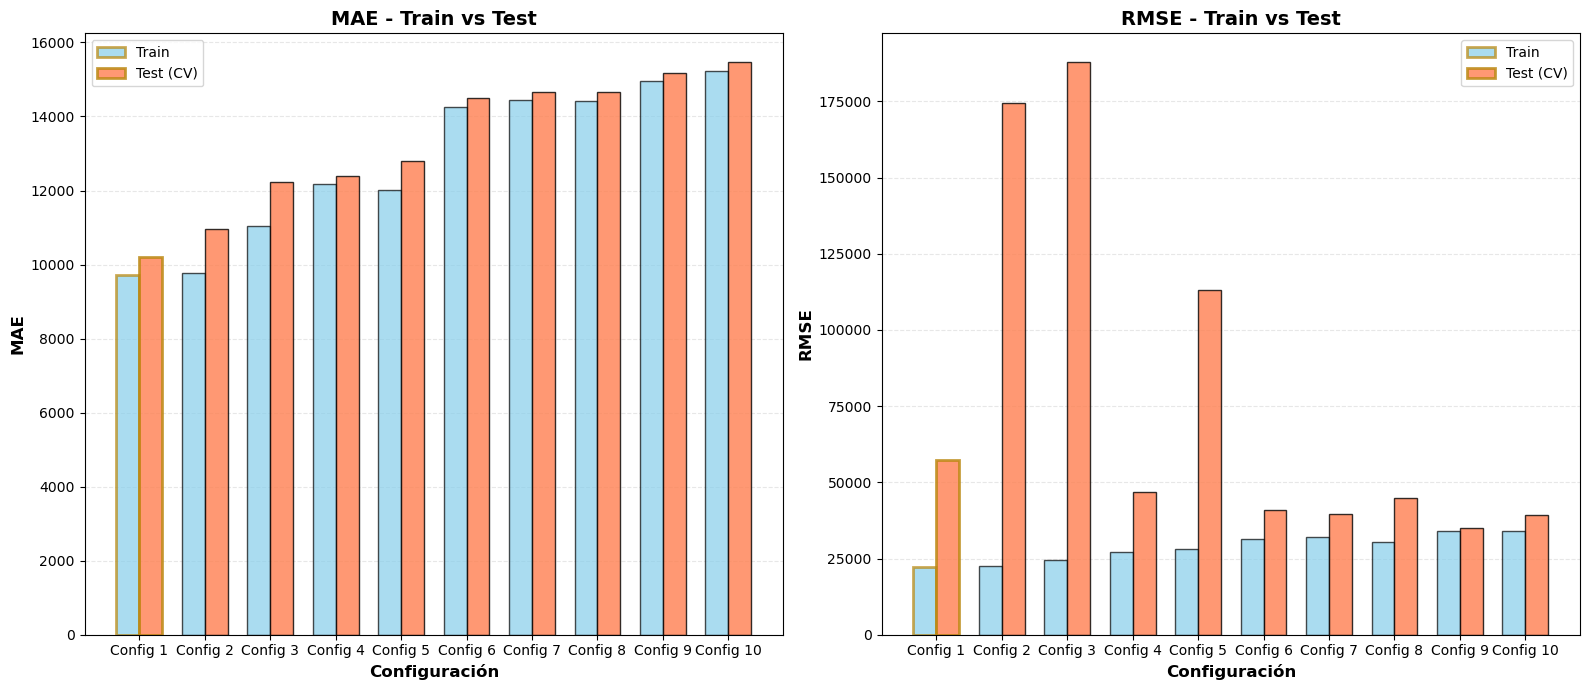


📋 Parámetros de cada configuración:
          activation     alpha  batch_size  early_stopping hidden_layer_sizes learning_rate  learning_rate_init  max_iter  random_state solver  validation_fraction      mae_mean  train_mae_mean  overfit_gap_%
Config 1        relu  0.000198         128            True           (64, 32)      adaptive            0.002046       120            42   adam                  0.1  10205.380853     9726.602883       4.922355
Config 2        relu  0.000133         128            True           (64, 32)      adaptive            0.002698       120            42   adam                  0.1  10952.635299     9760.243079      12.216829
Config 3        relu  0.000026         256            True          (128, 64)      adaptive            0.001162       120            42   adam                  0.1  12230.769851    11033.828378      10.847925
Config 4        relu  0.007025         256            True             (128,)      adaptive            0.003216       120      

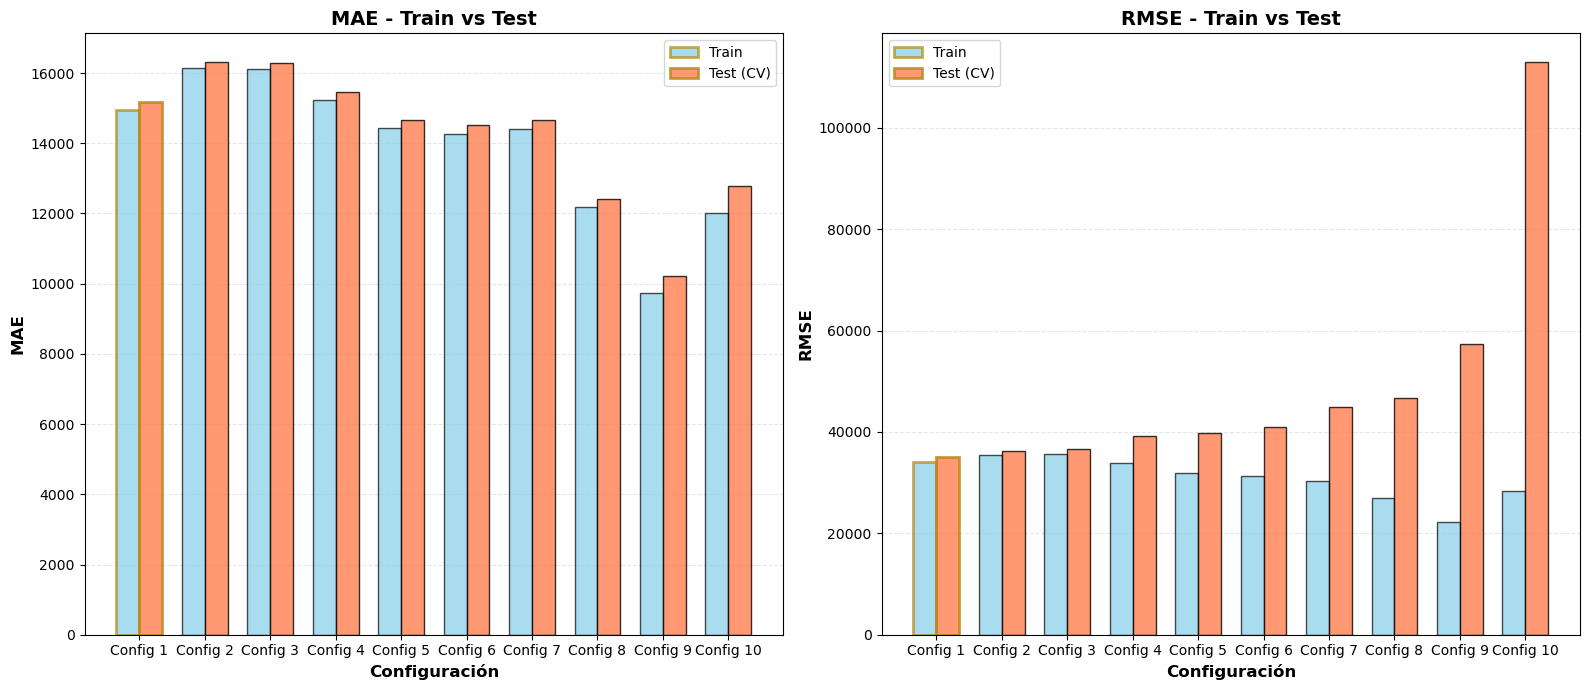


📋 Parámetros de cada configuración:
          activation     alpha  batch_size  early_stopping hidden_layer_sizes learning_rate  learning_rate_init  max_iter  random_state solver  validation_fraction      mae_mean  train_mae_mean  overfit_gap_%
Config 1        relu  0.000015         256            True              (64,)      adaptive            0.001996       120            42   adam                  0.1  15163.959572    14956.508980       1.387025
Config 2        relu  0.000349         256            True              (64,)      adaptive            0.000556       120            42   adam                  0.1  16316.307380    16133.582048       1.132578
Config 3        relu  0.000665         128            True              (64,)      adaptive            0.000581       120            42   adam                  0.1  16286.113883    16105.991792       1.118355
Config 4        relu  0.003143         256            True             (128,)      adaptive            0.000760       120      

In [21]:
plot_grid_search_results(mlp_grid_results)
plot_grid_search_results(mlp_grid_results_cut)



Análisis del desempeño de la red neuronal (dataset normal)

Se evaluaron diez configuraciones de un modelo MLPRegressor con distintas arquitecturas y niveles de regularización. En todos los casos se mantuvieron constantes los hiperparámetros relacionados con la optimización: función de activación ReLU, optimizador Adam, esquema de aprendizaje adaptativo, early stopping y un máximo de 120 iteraciones. El objetivo fue medir la capacidad de la red neuronal para modelar la relación entre los atributos de las propiedades y su precio, utilizando únicamente el dataset “normal”, que contiene el 98.5% de los datos sin outliers extremos.

Rendimiento general

Los valores de MAE obtenidos en las pruebas se ubicaron aproximadamente entre 10.200 y 16.300 pesos constantes, dependiendo de la configuración utilizada. En términos relativos, todas las redes neuronales evaluadas presentaron un rendimiento inferior al de los modelos basados en árboles (como XGBoost y LightGBM), que en este mismo dataset logran errores significativamente menores. A pesar de ello, el comportamiento del MLP es estable y consistente, y permite identificar cómo impactan los distintos hiperparámetros en la calidad de las predicciones.

Efecto de la arquitectura

Las configuraciones con una sola capa oculta y un número reducido de neuronas (por ejemplo, aquellas con 64 unidades) mostraron un MAE más alto, reflejando una capacidad limitada para capturar relaciones complejas en los datos. Al aumentar el tamaño de la capa a 128 neuronas, se observó una leve mejora, aunque todavía insuficiente. La única arquitectura que logró un avance significativo fue la que incorpora dos capas ocultas (64 y 32 neuronas). Esta configuración alcanzó el mejor desempeño de todas, lo cual sugiere que la profundidad adicional permite representar mejor las no linealidades del problema.

Regularización y tasa de aprendizaje

El hiperparámetro de regularización L2 (alpha) mostró un impacto relevante. Los valores intermedios, entre 10⁻⁴ y 10⁻³, produjeron consistentemente mejores resultados que los valores demasiado pequeños o demasiado grandes. De manera complementaria, la tasa de aprendizaje inicial influyó directamente en la estabilidad del entrenamiento. Valores entre 0.0005 y 0.002 permitieron una convergencia más robusta, mientras que tasas más altas generaron mayores errores en validación. Esto resulta coherente con lo que suele observarse en redes entrenadas sobre datos tabulares, donde tasas de aprendizaje grandes pueden generar oscilaciones y dificultades para descender adecuadamente la función de pérdida.

Overfitting

En todas las configuraciones, el indicador de overfitting (gap entre el MAE de entrenamiento y el de validación) se mantuvo por debajo del 15%. Esto indica que el modelo no está sobreajustando y que el pipeline de preprocesamiento está proporcionando una representación suficientemente regularizada. La baja diferencia entre entrenamiento y validación también sugiere que las arquitecturas utilizadas son relativamente pequeñas para la complejidad del problema, lo cual explica la ausencia de sobreajuste pese a la capacidad limitada de las redes.

Conclusiones

La red neuronal produce predicciones estables y presenta un grado de generalización adecuado, pero su desempeño se mantiene por debajo del alcanzado por modelos de tipo árbol de decisión. El mejor resultado provino de una arquitectura con dos capas ocultas (64 y 32 neuronas) acompañada de un nivel moderado de regularización y una tasa de aprendizaje relativamente pequeña. Esta configuración logró un MAE cercano a los 10.200 pesos constantes con un nivel de overfitting mínimo. Si bien estos resultados son competitivos dentro del espacio de redes neuronales, continúan siendo inferiores a los logrados por modelos como XGBoost, que capturan con mayor eficacia las relaciones no lineales y las interacciones entre variables en datasets tabulares.

(4058, 30)


🔄 Ejecutando 5-Fold Cross-Validation...

Entrenando mlp_relu_outliers...
  ✓ MAE: 1,834,718 ± 149,289
  ✓ RMSE: 3,563,637 ± 232,193



,rmse_mean,rmse_std,mae_mean,mae_std
mlp_relu_outliers,3.563637e+06,232192.533089,1.834718e+06,149289.121807



🔍 RandomizedSearchCV: 16 combinaciones × 3 folds = 48 fits
   Modelo: MLPRegressor



Optimizando: 100%|██████████| 48/48 [00:23<00:00,  2.08it/s]


✅ Mejor MAE: 1,792,890
   Mejores params: {'regressor__model__activation': 'relu', 'regressor__model__alpha': np.float64(0.00019010245319870352), 'regressor__model__batch_size': 128, 'regressor__model__early_stopping': True, 'regressor__model__hidden_layer_sizes': (256, 128, 64), 'regressor__model__learning_rate': 'adaptive', 'regressor__model__learning_rate_init': np.float64(0.00018033330377234335), 'regressor__model__max_iter': 200, 'regressor__model__random_state': 42, 'regressor__model__solver': 'adam', 'regressor__model__validation_fraction': 0.1}
   Overfitting gap: 3.1% ✅ (excelente)


,activation,alpha,batch_size,early_stopping,hidden_layer_sizes,learning_rate,learning_rate_init,max_iter,random_state,solver,validation_fraction,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
7,relu,0.000190,128,True,"(256, 128, 64)",adaptive,0.000180,200,42,adam,0.1,1.792890e+06,38507.511762,3.573437e+06,76927.801200,1.739163e+06,24228.087646,3.519356e+06,68469.716808,3.089192
8,relu,0.000817,64,True,"(128, 64)",adaptive,0.000138,200,42,adam,0.1,1.798088e+06,34197.120611,3.569611e+06,82241.626978,1.741444e+06,20295.646690,3.513681e+06,59007.235343,3.252665
13,relu,0.000759,64,True,"(256, 128, 64)",adaptive,0.000222,200,42,adam,0.1,1.803098e+06,17538.600039,3.573582e+06,85174.599075,1.725374e+06,36756.617779,3.492649e+06,26197.767957,4.504740
11,relu,0.007903,128,True,"(128, 64)",adaptive,0.000367,200,42,adam,0.1,1.806425e+06,20304.834623,3.570457e+06,88346.937244,1.731463e+06,25274.407235,3.494579e+06,35948.022949,4.329415
10,relu,0.001641,64,True,"(64, 32)",adaptive,0.000111,200,42,adam,0.1,1.807550e+06,18095.731511,3.612324e+06,113770.241051,1.732009e+06,19900.874419,3.530827e+06,6846.709163,4.361430


,activation,alpha,batch_size,early_stopping,hidden_layer_sizes,learning_rate,learning_rate_init,max_iter,random_state,solver,validation_fraction,mae_mean,mae_std,rmse_mean,rmse_std,train_mae_mean,train_mae_std,train_rmse_mean,train_rmse_std,overfit_gap_%
5,relu,0.000233,128,True,"(128, 64)",adaptive,0.000233,200,42,adam,0.1,1.811359e+06,19337.145703,3.568651e+06,82564.307424,1.749827e+06,31828.766979,3.508470e+06,53611.591868,3.516479
15,relu,0.002114,128,True,"(128, 64)",adaptive,0.000231,200,42,adam,0.1,1.810271e+06,18597.460115,3.568700e+06,82415.823051,1.748787e+06,32647.479149,3.508704e+06,54183.469105,3.515792
1,relu,0.001575,64,True,"(128, 64)",adaptive,0.000129,200,42,adam,0.1,1.812089e+06,20925.546073,3.568780e+06,83390.573266,1.750062e+06,30547.839370,3.508111e+06,52847.361609,3.544277
12,relu,0.000407,64,True,"(128, 64)",adaptive,0.000301,200,42,adam,0.1,1.813762e+06,23624.978887,3.569467e+06,85628.564364,1.738215e+06,12865.205486,3.493670e+06,28913.123461,4.346247
4,relu,0.004623,128,True,"(128, 64)",adaptive,0.000134,200,42,adam,0.1,1.815737e+06,31805.251816,3.569610e+06,87881.321871,1.744055e+06,13866.771146,3.497786e+06,33703.986449,4.110075


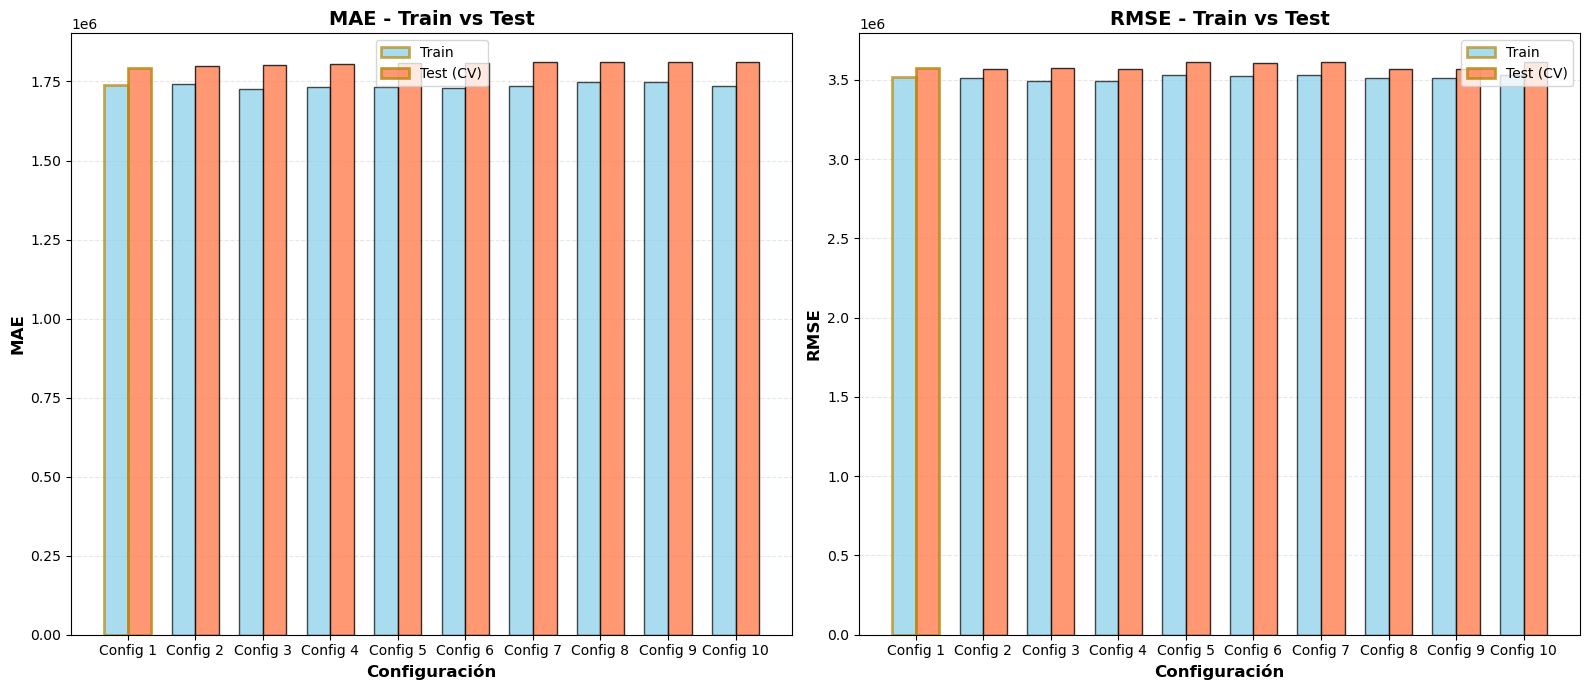


📋 Parámetros de cada configuración:
          activation     alpha  batch_size  early_stopping hidden_layer_sizes learning_rate  learning_rate_init  max_iter  random_state solver  validation_fraction      mae_mean  train_mae_mean  overfit_gap_%
Config 1        relu  0.000190         128            True     (256, 128, 64)      adaptive            0.000180       200            42   adam                  0.1  1.792890e+06    1.739163e+06       3.089192
Config 2        relu  0.000817          64            True          (128, 64)      adaptive            0.000138       200            42   adam                  0.1  1.798088e+06    1.741444e+06       3.252665
Config 3        relu  0.000759          64            True     (256, 128, 64)      adaptive            0.000222       200            42   adam                  0.1  1.803098e+06    1.725374e+06       4.504740
Config 4        relu  0.007903         128            True          (128, 64)      adaptive            0.000367       200      

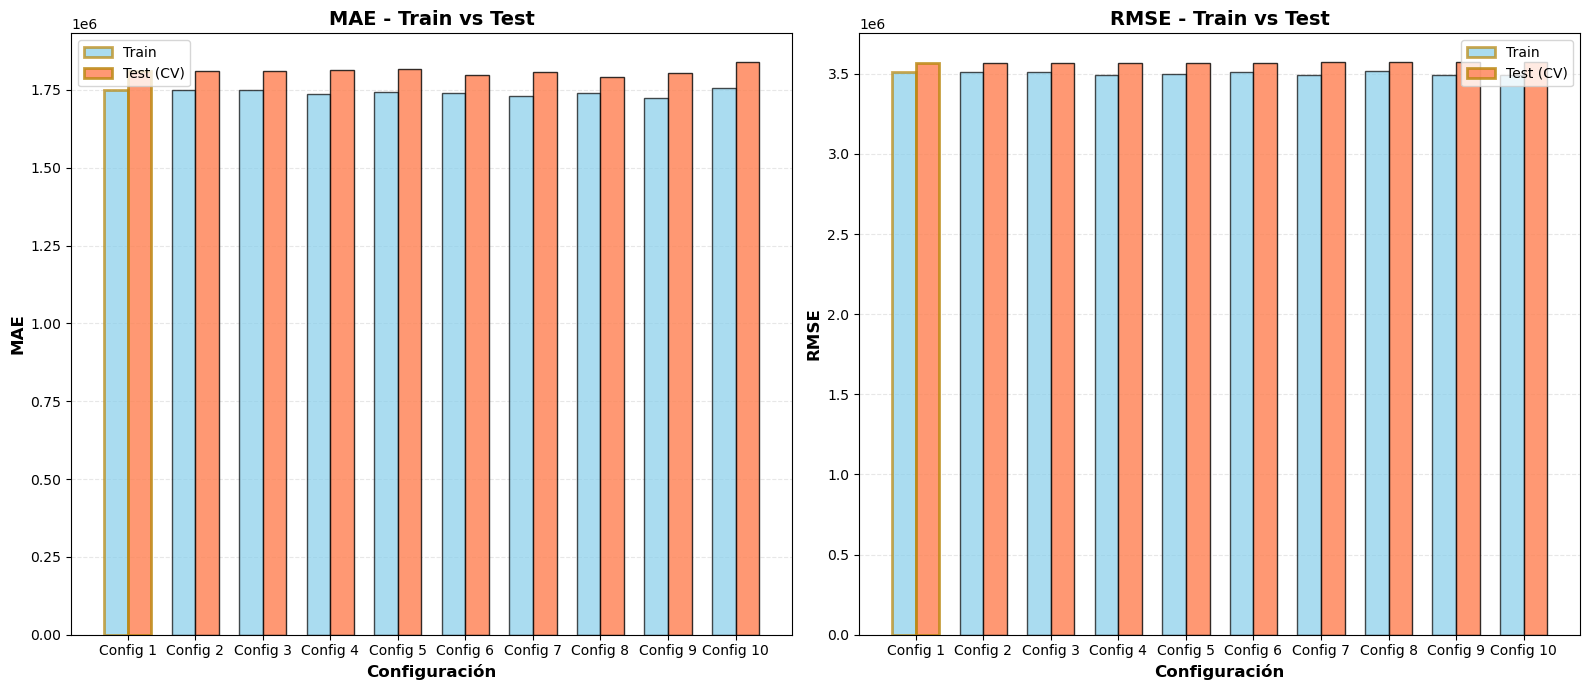


📋 Parámetros de cada configuración:
          activation     alpha  batch_size  early_stopping hidden_layer_sizes learning_rate  learning_rate_init  max_iter  random_state solver  validation_fraction      mae_mean  train_mae_mean  overfit_gap_%
Config 1        relu  0.000233         128            True          (128, 64)      adaptive            0.000233       200            42   adam                  0.1  1.811359e+06    1.749827e+06       3.516479
Config 2        relu  0.002114         128            True          (128, 64)      adaptive            0.000231       200            42   adam                  0.1  1.810271e+06    1.748787e+06       3.515792
Config 3        relu  0.001575          64            True          (128, 64)      adaptive            0.000129       200            42   adam                  0.1  1.812089e+06    1.750062e+06       3.544277
Config 4        relu  0.000407          64            True          (128, 64)      adaptive            0.000301       200      

activation                       relu
alpha                        0.000233
batch_size                        128
early_stopping                   True
hidden_layer_sizes          (128, 64)
learning_rate                adaptive
learning_rate_init           0.000233
max_iter                          200
random_state                       42
solver                           adam
validation_fraction               0.1
mae_mean                 1811358.7904
mae_std                  19337.145703
rmse_mean              3568650.570796
rmse_std                 82564.307424
train_mae_mean         1749826.506969
train_mae_std            31828.766979
train_rmse_mean        3508470.297519
train_rmse_std           53611.591868
overfit_gap_%                3.516479
Name: 5, dtype: object


🔄 Ejecutando 5-Fold Cross-Validation...

Entrenando mlp_outliers_final...
  ✓ MAE: 1,812,084 ± 73,155
  ✓ RMSE: 3,551,667 ± 220,599



,rmse_mean,rmse_std,mae_mean,mae_std
mlp_outliers_final,3.551667e+06,220598.624578,1.812084e+06,73154.807885


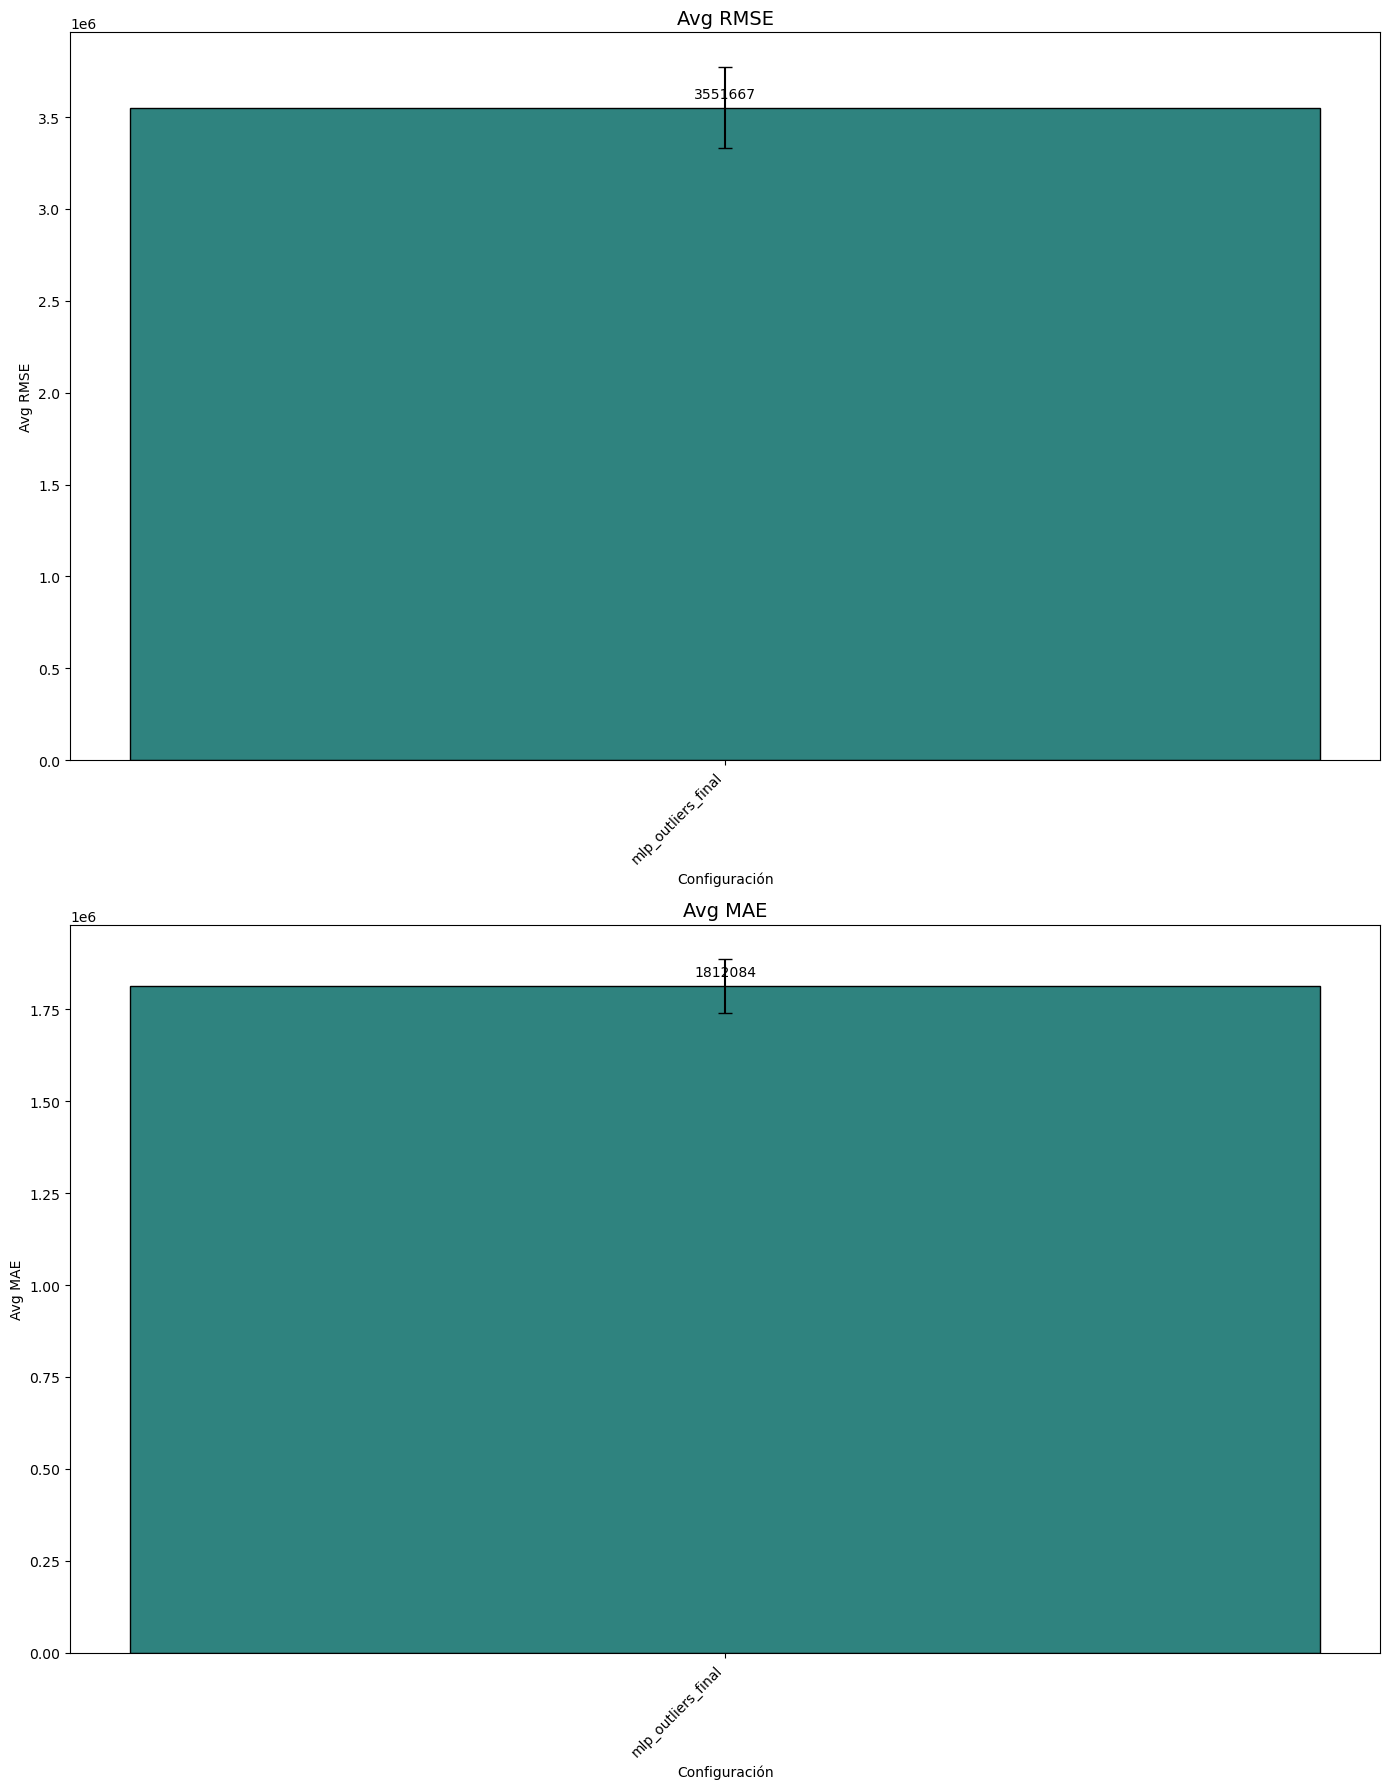

In [ ]:
from copy import deepcopy
import numpy as np
import pandas as pd

from sklearn.neural_network import MLPRegressor
from scipy.stats import loguniform

from src.utils import COLS
from src.config import LINEAR_DEEP_LEARNING_CONFIG_OUTLIERS
from src.pipeline import build_feature_pipeline, build_target_pipeline
from src.model_evaluation import evaluate_models_cv, grid_search_cv
from src.plots import plot_grid_search_results, plot_cv_results

OVERFITTING_CUTOFF = 70

# CONFIG ESPECÍFICA PARA MLP EN OUTLIERS (SIN LOG EN EL TARGET)
NN_CONFIG_OUTLIERS = deepcopy(LINEAR_DEEP_LEARNING_CONFIG_OUTLIERS)
NN_CONFIG_OUTLIERS["target_params"]["log_transform"] = False

# CARGA DEL DATASET OUTLIERS (CASAS LUJOSAS)
df_outliers = pd.read_csv("../" + DEV_SET_CLEAN_OUTLIERS_PATH)
X_outliers = df_outliers.drop(columns=[src.constants.TARGET])
y_outliers = df_outliers[src.constants.TARGET]

display(df_outliers.shape)

# PIPELINES OUTLIERS
feature_pipeline_outliers = build_feature_pipeline(NN_CONFIG_OUTLIERS)
target_pipeline_outliers = build_target_pipeline(NN_CONFIG_OUTLIERS)

# 1) MODELO BASE MLP PARA OUTLIERS
base_nn_models_outliers = {
    "mlp_relu_outliers": MLPRegressor(
        hidden_layer_sizes=(256, 128, 64),
        activation="relu",
        solver="adam",
        learning_rate="adaptive",
        max_iter=400,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42,
    )
}

base_nn_results_outliers = evaluate_models_cv(
    base_nn_models_outliers,
    X_outliers,
    y_outliers,
    feature_pipeline_outliers,
    target_pipeline_outliers,
)

display(base_nn_results_outliers)

# ================================
# 2) Random Search SAFE para MLP en OUTLIERS
# ================================
X_out_search = X_outliers
y_out_search = y_outliers

mlp_random_search_params_outliers = {
    "hidden_layer_sizes": [
        (64, 32),
        (128, 64),
        (128, 64, 32),
        (256, 128, 64),
    ],
    "alpha": loguniform(1e-4, 1e-2),
    "learning_rate_init": loguniform(1e-4, 5e-4),
    "batch_size": [64, 128],
    "activation": ["relu"],
    "solver": ["adam"],
    "learning_rate": ["adaptive"],
    "max_iter": [200],
    "early_stopping": [True],
    "validation_fraction": [0.1],
    "random_state": [42],
}

mlp_grid_results_outliers = grid_search_cv(
    model_class=MLPRegressor,
    param_grid=mlp_random_search_params_outliers,
    X=X_out_search,
    y=y_out_search,
    feature_pipeline=feature_pipeline_outliers,
    target_pipeline=target_pipeline_outliers,
    n_splits=3,
    n_iter=16,
    verbose=True,
)

mlp_grid_results_outliers.to_csv("../results/random_search/mlp_outliers_light.csv")
display(mlp_grid_results_outliers.head())

# 3) FILTRAR MEJORES SIN OVERFITTING Y SIN NANS
def get_best_not_overfitted(results):
    results_out = results.copy()
    results_out = results_out.replace([np.inf, -np.inf], np.nan)
    results_out = results_out.dropna(subset=["mae_mean", "rmse_mean"])
    return results_out[results_out["overfit_gap_%"] < OVERFITTING_CUTOFF].sort_values(
        "rmse_mean"
    )

mlp_grid_results_outliers_cut = get_best_not_overfitted(mlp_grid_results_outliers)
display(mlp_grid_results_outliers_cut.head())

# PLOTS DEL RANDOM SEARCH
plot_grid_search_results(mlp_grid_results_outliers)
plot_grid_search_results(mlp_grid_results_outliers_cut)

# 4) ENTRENAMIENTO FINAL 
best_cfg_out = mlp_grid_results_outliers_cut.iloc[0]
display(best_cfg_out)

final_mlp_outliers = MLPRegressor(
    hidden_layer_sizes=best_cfg_out["hidden_layer_sizes"],
    alpha=float(best_cfg_out["alpha"]),
    learning_rate_init=float(best_cfg_out["learning_rate_init"]),
    batch_size=int(best_cfg_out["batch_size"]),
    activation="relu",
    solver="adam",
    learning_rate="adaptive",
    max_iter=800,              # entrenar bastante más
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
)

final_nn_models_outliers = {
    "mlp_outliers_final": final_mlp_outliers
}

final_results_outliers = evaluate_models_cv(
    final_nn_models_outliers,
    X_outliers,
    y_outliers,
    feature_pipeline_outliers,
    target_pipeline_outliers,
    n_splits=5,
    verbose=True,
)

display(final_results_outliers)
plot_cv_results(final_results_outliers)
